# 12. Backtest with the directional model from nb 11

**Hypothesis**: the nb 11 expanded model found a weekly directional signal
(pooled RF on `log_forward_ret`, Spearman +0.12, Q5-Q1 spread +2.74% / week).
Does it translate to options PnL when used as an entry filter?

**Setup**: retrain the nb 11 best model on the train split (pre-2025-05-19,
5,338 rows) and score the test window. Use the prediction quantile
cross-sectionally each Monday to gate entries.

**CSP intuition**: we want to sell CSP on names predicted *up* — they won't
breach the put strike, we keep the premium, no assignment. Skip names
predicted *down* — those are the ones that get assigned at a loss.

**CC intuition**: we want to sell CC on names predicted *down* (or flat) —
they won't run past the call strike, we keep premium and shares. Skip names
predicted *up* — those get called away, capping our upside.

**Combined wheel**: per (ticker, monday), pick CSP if prediction is top half,
CC if bottom half. This uses the signal both ways rather than leaving one
direction on the table.

**Baselines**: the nb 10 baseline (take every CSP at 1% yield) and a
symmetric "take every CC at 1% yield" comparison.

In [1]:
import math
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

from config import HIGH_QUALITY_TICKERS

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
DAILY_YF_DIR = Path("data/daily_yf")
OUT_DIR = Path("output/12_directional_model_backtest")
OUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

YIELD_TARGET = 0.01
TEST_START = pd.Timestamp("2025-06-02")
TRAIN_CUTOFF = pd.Timestamp("2025-05-19")  # matches nb 11 split

MARKET_TICKERS = [
    "SPY",
    "VIX",
    "VIX9D",
    "TNX",
    "IRX",
    "HYG",
    "LQD",
    "UUP",
    "GLD",
    "USO",
    "XLK",
    "XLP",
    "XLY",
]

# Pruned feature set from nb 11's multicollinearity screen
PRUNED_FEATURES = [
    "ret_5d",
    "ret_20d",
    "ret_60d",
    "vol_20d",
    "vol_ratio_20_60",
    "close_to_ma20",
    "ma20_to_ma50",
    "max_dd_60d",
    "dist_from_52w_high",
    "rsi_14",
    "volume_ratio_20d",
    "log_volume",
    "spy_ret_20d",
    "spy_vol_20d",
    "vix_level",
    "vix_change_5d",
    "vix_change_20d",
    "vix9d_vix_ratio",
    "tnx_level",
    "tnx_change_5d",
    "tnx_change_20d",
    "yield_curve_slope",
    "credit_spread_proxy",
    "uup_ret_20d",
    "gld_ret_20d",
    "uso_ret_20d",
    "xlk_minus_spy_20d",
    "xly_minus_xlp_20d",
]
print(f"{len(PRUNED_FEATURES)} features (pruned, from nb 11)")

28 features (pruned, from nb 11)


## Rebuild features (inlined from nb 11)

Keep this notebook self-contained: same feature computation as nb 11, so the
model we train here is reproducible without depending on nb 11 running first.

In [2]:
def compute_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def compute_features_expanded(ticker_df, market):
    close = ticker_df["adjusted_close"]
    volume = ticker_df["volume"]
    log_ret = np.log(close / close.shift(1))
    feat = pd.DataFrame(index=ticker_df.index)

    feat["ret_5d"] = close / close.shift(5) - 1
    feat["ret_20d"] = close / close.shift(20) - 1
    feat["ret_60d"] = close / close.shift(60) - 1
    feat["vol_20d"] = log_ret.rolling(20).std() * np.sqrt(252)
    feat["vol_60d"] = log_ret.rolling(60).std() * np.sqrt(252)
    feat["vol_ratio_20_60"] = feat["vol_20d"] / feat["vol_60d"]

    ma20 = close.rolling(20).mean()
    ma50 = close.rolling(50).mean()
    feat["close_to_ma20"] = close / ma20 - 1
    feat["ma20_to_ma50"] = ma20 / ma50 - 1

    feat["max_dd_60d"] = close / close.rolling(60).max() - 1
    feat["dist_from_52w_high"] = close / close.rolling(252).max() - 1
    feat["rsi_14"] = compute_rsi(close, 14)
    feat["volume_ratio_20d"] = volume / volume.rolling(20).mean()
    feat["log_volume"] = np.log(volume.replace(0, 1))

    spy = market["SPY"]["adjusted_close"]
    spy_lr = np.log(spy / spy.shift(1))
    mk = pd.DataFrame(index=spy.index)
    mk["spy_ret_20d"] = spy / spy.shift(20) - 1
    mk["spy_vol_20d"] = spy_lr.rolling(20).std() * np.sqrt(252)

    vix = market["VIX"]["adjusted_close"]
    vix9d = market["VIX9D"]["adjusted_close"]
    mk["vix_level"] = vix.reindex(spy.index)
    mk["vix_change_5d"] = vix.reindex(spy.index).pct_change(5)
    mk["vix_change_20d"] = vix.reindex(spy.index).pct_change(20)
    mk["vix9d_vix_ratio"] = (vix9d / vix).reindex(spy.index)

    tnx = market["TNX"]["adjusted_close"]
    irx = market["IRX"]["adjusted_close"]
    mk["tnx_level"] = tnx.reindex(spy.index)
    mk["tnx_change_5d"] = tnx.reindex(spy.index).diff(5)
    mk["tnx_change_20d"] = tnx.reindex(spy.index).diff(20)
    mk["yield_curve_slope"] = (tnx - irx).reindex(spy.index)

    hyg = market["HYG"]["adjusted_close"]
    lqd = market["LQD"]["adjusted_close"]
    mk["credit_spread_proxy"] = (hyg.pct_change(20) - lqd.pct_change(20)).reindex(
        spy.index
    )

    mk["uup_ret_20d"] = (
        market["UUP"]["adjusted_close"].pct_change(20).reindex(spy.index)
    )
    mk["gld_ret_20d"] = (
        market["GLD"]["adjusted_close"].pct_change(20).reindex(spy.index)
    )
    mk["uso_ret_20d"] = (
        market["USO"]["adjusted_close"].pct_change(20).reindex(spy.index)
    )

    xlk = market["XLK"]["adjusted_close"]
    xlp = market["XLP"]["adjusted_close"]
    xly = market["XLY"]["adjusted_close"]
    spy_20 = spy.pct_change(20)
    mk["xlk_minus_spy_20d"] = (xlk.pct_change(20) - spy_20).reindex(spy.index)
    mk["xly_minus_xlp_20d"] = (xly.pct_change(20) - xlp.pct_change(20)).reindex(
        spy.index
    )

    return feat.join(mk, how="left")


daily_yf = {}
for t in HIGH_QUALITY_TICKERS:
    p = DAILY_YF_DIR / f"{t}.csv"
    if not p.exists():
        continue
    df = pd.read_csv(p, parse_dates=["date"]).set_index("date").sort_index()
    daily_yf[t] = df

market = {}
for t in MARKET_TICKERS:
    p = DAILY_YF_DIR / f"{t}.csv"
    df = pd.read_csv(p, parse_dates=["date"]).set_index("date").sort_index()
    if df["adjusted_close"].isna().all():
        df["adjusted_close"] = df["close"]
    market[t] = df

features_by_ticker = {
    t: compute_features_expanded(daily_yf[t], market) for t in daily_yf
}
print(f"computed features for {len(features_by_ticker)} tickers")

computed features for 35 tickers


## Build (ticker, monday) feature table + forward return target

In [3]:
labels = pd.read_parquet(LABELS_PATH)
labels["monday_date"] = pd.to_datetime(labels["monday_date"])

keys = labels[
    ["ticker", "monday_date", "monday_close", "friday_date", "friday_close"]
].drop_duplicates()
keys["friday_date"] = pd.to_datetime(keys["friday_date"])

rows = []
for r in keys.itertuples():
    tf = features_by_ticker.get(r.ticker)
    if tf is None:
        continue
    try:
        fvals = (
            tf.loc[r.monday_date]
            if r.monday_date in tf.index
            else tf.loc[: r.monday_date].iloc[-1]
        )
    except KeyError, IndexError:
        continue
    rec = {
        "ticker": r.ticker,
        "monday_date": r.monday_date,
        "friday_date": r.friday_date,
        "monday_close": r.monday_close,
        "friday_close": r.friday_close,
    }
    for f in PRUNED_FEATURES:
        rec[f] = fvals.get(f, np.nan)
    rows.append(rec)

feat = pd.DataFrame(rows)
feat["log_forward_ret"] = np.log(feat["friday_close"] / feat["monday_close"])
feat = feat.dropna(subset=PRUNED_FEATURES).reset_index(drop=True)
print(f"{len(feat):,} (ticker, monday) rows after feature NaN drop")

6,711 (ticker, monday) rows after feature NaN drop


## Train model on pre-test split, score the test window

In [4]:
train_mask = feat["monday_date"] < TRAIN_CUTOFF
test_mask = feat["monday_date"] >= TRAIN_CUTOFF

X_train = feat.loc[train_mask, PRUNED_FEATURES].values
y_train = feat.loc[train_mask, "log_forward_ret"].values
X_test = feat.loc[test_mask, PRUNED_FEATURES].values

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=SEED,
)
model.fit(X_train, y_train)
preds_test = model.predict(X_test)

pred_df = feat.loc[test_mask, ["ticker", "monday_date"]].copy()
pred_df["pred_log_forward_ret"] = preds_test
pred_df["pred_forward_ret"] = np.exp(preds_test) - 1
print(f"trained on {train_mask.sum():,} rows, scored {test_mask.sum():,} test rows")
print(
    f"prediction summary: min={preds_test.min():.4f} median={np.median(preds_test):.4f} "
    f"max={preds_test.max():.4f}"
)

trained on 5,338 rows, scored 1,373 test rows
prediction summary: min=-0.0518 median=0.0024 max=0.0635


## Assemble CSP + CC candidates for the test window

For each (ticker, monday) in the test window, pull both the CSP and CC rows at
the 1% yield target from `strategy_labels.parquet`, then join the prediction.

In [5]:
def build_candidates(type_label: str) -> pd.DataFrame:
    df = labels[
        (labels["type"] == type_label)
        & (labels["yield_target"] == YIELD_TARGET)
        & (labels["monday_date"] >= TEST_START)
    ].copy()
    df = df.merge(pred_df, on=["ticker", "monday_date"], how="left")
    df = df.dropna(subset=["pred_log_forward_ret"]).reset_index(drop=True)
    # Cross-sectional rank: for each Monday, where does this ticker's prediction fall
    df["pred_rank_pct"] = df.groupby("monday_date")["pred_log_forward_ret"].rank(
        pct=True
    )
    return df


csp = build_candidates("CSP")
cc = build_candidates("CC")
print(f"CSP candidates: {len(csp):,}")
print(f"CC  candidates: {len(cc):,}")
print(
    f"  test weeks: {csp['monday_date'].nunique()}, tickers: {csp['ticker'].nunique()}"
)
print(f"  CSP baseline fill rate: {csp['assigned'].mean():.3f}")
print(f"  CC  baseline fill rate: {cc['assigned'].mean():.3f}")

CSP candidates: 1,167
CC  candidates: 1,222
  test weeks: 39, tickers: 35
  CSP baseline fill rate: 0.269
  CC  baseline fill rate: 0.214


## Strategy definitions

Each strategy returns a boolean mask over the candidate dataframe marking
which rows are *entered*. Skipped rows contribute 0 to the weekly portfolio.

**CSP strategies** (want predicted UP — stock stays above put strike):
- `CSP_baseline`: take every CSP
- `CSP_top_half`: only take when prediction above cross-sectional median
- `CSP_top_quintile`: only take the top 20% by prediction each Monday
- `CSP_skip_bottom_quintile`: take all EXCEPT the bottom 20%

**CC strategies** (want predicted DOWN — stock stays below call strike):
- `CC_baseline`: take every CC
- `CC_bottom_half`: only take when prediction below cross-sectional median
- `CC_bottom_quintile`: only take the bottom 20% by prediction each Monday
- `CC_skip_top_quintile`: take all EXCEPT the top 20%

In [6]:
def mk_strategies(kind: str) -> dict:
    if kind == "CSP":
        return {
            "CSP_baseline": lambda df: np.ones(len(df), dtype=bool),
            "CSP_top_half": lambda df: df["pred_rank_pct"] > 0.50,
            "CSP_top_quintile": lambda df: df["pred_rank_pct"] > 0.80,
            "CSP_skip_bottom_quintile": lambda df: df["pred_rank_pct"] > 0.20,
        }
    else:
        return {
            "CC_baseline": lambda df: np.ones(len(df), dtype=bool),
            "CC_bottom_half": lambda df: df["pred_rank_pct"] <= 0.50,
            "CC_bottom_quintile": lambda df: df["pred_rank_pct"] <= 0.20,
            "CC_skip_top_quintile": lambda df: df["pred_rank_pct"] <= 0.80,
        }


def run_strategies(df, strategies):
    out = {}
    for name, fn in strategies.items():
        entered = np.asarray(fn(df), dtype=bool)
        dd = df.copy()
        dd["entered"] = entered
        dd["strategy_pnl_pct"] = np.where(entered, dd["pnl_pct_capital"], 0.0)
        out[name] = dd
    return out


csp_runs = run_strategies(csp, mk_strategies("CSP"))
cc_runs = run_strategies(cc, mk_strategies("CC"))
for name, dd in {**csp_runs, **cc_runs}.items():
    n = int(dd["entered"].sum())
    fr = float(dd.loc[dd["entered"], "assigned"].mean()) if n else np.nan
    avg = float(dd.loc[dd["entered"], "pnl_pct_capital"].mean()) if n else np.nan
    print(f"  {name:<30} n={n:>4}/{len(dd):>4}  fill={fr:.3f}  avg_pnl_pct={avg:+.4f}")

  CSP_baseline                   n=1167/1167  fill=0.269  avg_pnl_pct=+0.0002
  CSP_top_half                   n= 581/1167  fill=0.287  avg_pnl_pct=-0.0001
  CSP_top_quintile               n= 243/1167  fill=0.251  avg_pnl_pct=+0.0002
  CSP_skip_bottom_quintile       n= 950/1167  fill=0.277  avg_pnl_pct=+0.0003
  CC_baseline                    n=1222/1222  fill=0.214  avg_pnl_pct=-0.0014
  CC_bottom_half                 n= 612/1222  fill=0.216  avg_pnl_pct=-0.0015
  CC_bottom_quintile             n= 228/1222  fill=0.162  avg_pnl_pct=-0.0033
  CC_skip_top_quintile           n= 965/1222  fill=0.228  avg_pnl_pct=-0.0012


## Portfolio metrics

Weekly portfolio = mean `pnl_pct_capital` across taken trades for that Monday
(0 contribution from skipped trades, matching nb 10's convention).

In [7]:
def portfolio_series(df):
    return df.groupby("monday_date")["strategy_pnl_pct"].mean().sort_index()


def metrics(weekly):
    if len(weekly) == 0:
        return dict(
            total_return=0, mean_weekly=0, std_weekly=0, sharpe=0, max_dd=0, n_weeks=0
        )
    cum = weekly.cumsum()
    dd = cum - cum.cummax()
    return dict(
        total_return=float(cum.iloc[-1]),
        mean_weekly=float(weekly.mean()),
        std_weekly=float(weekly.std()),
        sharpe=float(weekly.mean() / weekly.std() * math.sqrt(52))
        if weekly.std() > 0
        else 0.0,
        max_dd=float(dd.min()),
        n_weeks=int(len(weekly)),
    )


def summarize(runs: dict) -> pd.DataFrame:
    rows = []
    for name, dd in runs.items():
        w = portfolio_series(dd)
        m = metrics(w)
        n_tr = int(dd["entered"].sum())
        fr = float(dd.loc[dd["entered"], "assigned"].mean()) if n_tr else 0.0
        mpt = float(dd.loc[dd["entered"], "pnl_pct_capital"].mean()) if n_tr else 0.0
        rows.append(
            {
                "strategy": name,
                "n_trades": n_tr,
                "pct_weeks_traded": round(100 * dd["entered"].mean(), 1),
                "fill_rate_pct": round(100 * fr, 1),
                "mean_pnl_per_trade_pct": round(100 * mpt, 3),
                **{k: round(v, 4) for k, v in m.items() if k != "n_weeks"},
                "n_weeks": m["n_weeks"],
            }
        )
    return pd.DataFrame(rows)


csp_summary = summarize(csp_runs)
cc_summary = summarize(cc_runs)
print("CSP summary:")
print(csp_summary.to_string(index=False))
print()
print("CC summary:")
print(cc_summary.to_string(index=False))

CSP summary:
                strategy  n_trades  pct_weeks_traded  fill_rate_pct  mean_pnl_per_trade_pct  total_return  mean_weekly  std_weekly  sharpe  max_dd  n_weeks
            CSP_baseline      1167             100.0           26.9                   0.023        0.0095       0.0002      0.0083  0.2112 -0.0567       39
            CSP_top_half       581              49.8           28.7                  -0.012       -0.0024      -0.0001      0.0045 -0.0998 -0.0302       39
        CSP_top_quintile       243              20.8           25.1                   0.024        0.0022       0.0001      0.0023  0.1780 -0.0149       39
CSP_skip_bottom_quintile       950              81.4           27.7                   0.035        0.0116       0.0003      0.0066  0.3241 -0.0444       39

CC summary:
            strategy  n_trades  pct_weeks_traded  fill_rate_pct  mean_pnl_per_trade_pct  total_return  mean_weekly  std_weekly  sharpe  max_dd  n_weeks
         CC_baseline      1222            

## Equity curves

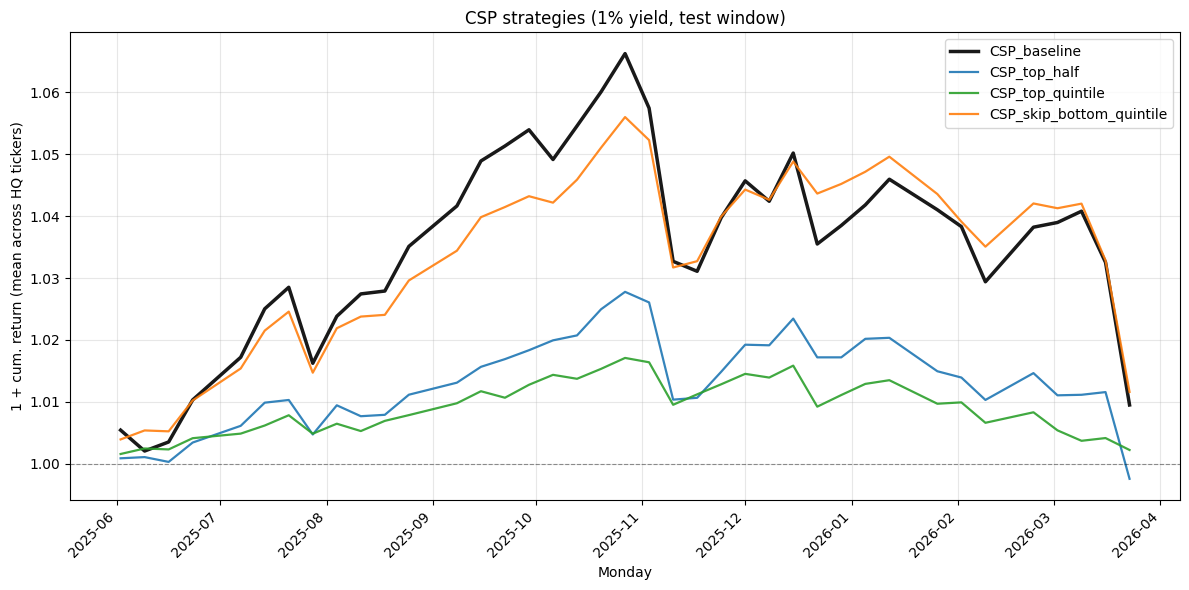

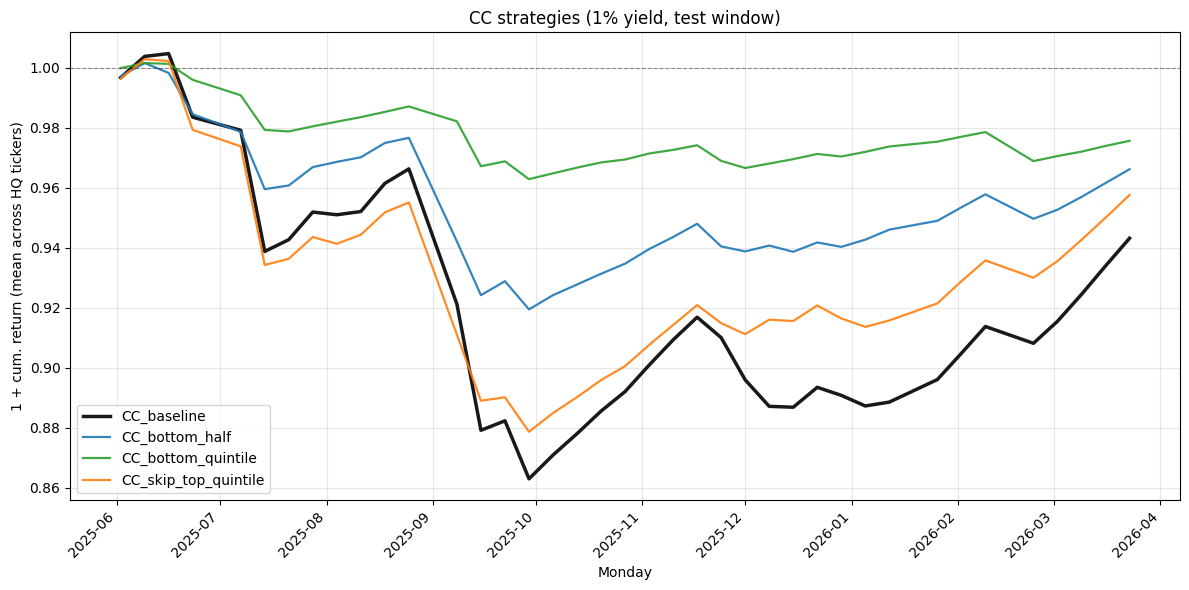

In [8]:
def plot_equity(runs, title, save_as, palette):
    fig, ax = plt.subplots(figsize=(12, 6))
    for name, dd in runs.items():
        w = portfolio_series(dd)
        equity = 1 + w.cumsum()
        lw = 2.5 if "baseline" in name else 1.6
        ax.plot(
            equity.index,
            equity.values,
            label=name,
            color=palette.get(name, "tab:gray"),
            linewidth=lw,
            alpha=0.9,
        )
    ax.axhline(1.0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.set_ylabel("1 + cum. return (mean across HQ tickers)")
    ax.set_xlabel("Monday")
    ax.set_title(title)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)
    fig.tight_layout()
    fig.savefig(OUT_DIR / save_as, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)


csp_palette = {
    "CSP_baseline": "black",
    "CSP_top_half": "tab:blue",
    "CSP_top_quintile": "tab:green",
    "CSP_skip_bottom_quintile": "tab:orange",
}
cc_palette = {
    "CC_baseline": "black",
    "CC_bottom_half": "tab:blue",
    "CC_bottom_quintile": "tab:green",
    "CC_skip_top_quintile": "tab:orange",
}
plot_equity(
    csp_runs, "CSP strategies (1% yield, test window)", "csp_equity.png", csp_palette
)
plot_equity(
    cc_runs, "CC strategies (1% yield, test window)", "cc_equity.png", cc_palette
)

## Combined directional wheel

Per (ticker, monday): pick CSP if predicted top half, CC if predicted bottom half.
This uses the signal on both sides rather than only one. We compare against the
"stack both always" baseline (sell both CSP and CC every week).

In [9]:
# Build a joint candidate table by merging CSP and CC on (ticker, monday_date)
joint = (
    csp[
        [
            "ticker",
            "monday_date",
            "pred_log_forward_ret",
            "pred_rank_pct",
            "pnl_pct_capital",
            "assigned",
        ]
    ]
    .rename(columns={"pnl_pct_capital": "csp_pnl_pct", "assigned": "csp_assigned"})
    .merge(
        cc[["ticker", "monday_date", "pnl_pct_capital", "assigned"]].rename(
            columns={"pnl_pct_capital": "cc_pnl_pct", "assigned": "cc_assigned"}
        ),
        on=["ticker", "monday_date"],
        how="inner",
    )
)
print(f"joint (CSP+CC both present): {len(joint):,} rows")

# Strategies:
# - stack_both_baseline: take CSP AND CC every week (mean their PnL)
# - directional_wheel: CSP if top half, CC if bottom half
# - directional_wheel_quintile: CSP if top quintile, CC if bottom quintile, skip middle
joint["stack_both_pnl"] = 0.5 * (joint["csp_pnl_pct"] + joint["cc_pnl_pct"])
joint["directional_pick"] = np.where(joint["pred_rank_pct"] > 0.5, "CSP", "CC")
joint["directional_pnl"] = np.where(
    joint["directional_pick"] == "CSP",
    joint["csp_pnl_pct"],
    joint["cc_pnl_pct"],
)


# Quintile variant — skip middle 60%
def quintile_pnl(row):
    if row["pred_rank_pct"] > 0.8:
        return row["csp_pnl_pct"]
    if row["pred_rank_pct"] <= 0.2:
        return row["cc_pnl_pct"]
    return 0.0


joint["quintile_pnl"] = joint.apply(quintile_pnl, axis=1)
joint["quintile_entered"] = (joint["pred_rank_pct"] > 0.8) | (
    joint["pred_rank_pct"] <= 0.2
)

combined_runs = {
    "stack_both_baseline": joint.assign(
        entered=True,
        strategy_pnl_pct=joint["stack_both_pnl"],
        pnl_pct_capital=joint["stack_both_pnl"],
        assigned=0.5 * (joint["csp_assigned"] + joint["cc_assigned"]),
    ),
    "directional_wheel": joint.assign(
        entered=True,
        strategy_pnl_pct=joint["directional_pnl"],
        pnl_pct_capital=joint["directional_pnl"],
        assigned=np.where(
            joint["directional_pick"] == "CSP",
            joint["csp_assigned"],
            joint["cc_assigned"],
        ),
    ),
    "directional_wheel_quintile": joint.assign(
        entered=joint["quintile_entered"],
        strategy_pnl_pct=joint["quintile_pnl"],
        pnl_pct_capital=np.where(
            joint["quintile_entered"],
            np.where(
                joint["pred_rank_pct"] > 0.8, joint["csp_pnl_pct"], joint["cc_pnl_pct"]
            ),
            0.0,
        ),
        assigned=np.where(
            joint["pred_rank_pct"] > 0.8,
            joint["csp_assigned"],
            np.where(joint["pred_rank_pct"] <= 0.2, joint["cc_assigned"], 0),
        ),
    ),
}

combined_summary = summarize(combined_runs)
print("Combined strategies:")
print(combined_summary.to_string(index=False))

joint (CSP+CC both present): 1,122 rows
Combined strategies:
                  strategy  n_trades  pct_weeks_traded  fill_rate_pct  mean_pnl_per_trade_pct  total_return  mean_weekly  std_weekly  sharpe  max_dd  n_weeks
       stack_both_baseline      1122             100.0           24.4                  -0.042       -0.0198      -0.0005      0.0063 -0.5826 -0.0457       39
         directional_wheel      1122             100.0           25.2                  -0.128       -0.0555      -0.0014      0.0086 -1.1927 -0.0814       39
directional_wheel_quintile       435              38.8           21.1                  -0.216       -0.0362      -0.0009      0.0049 -1.3575 -0.0415       39


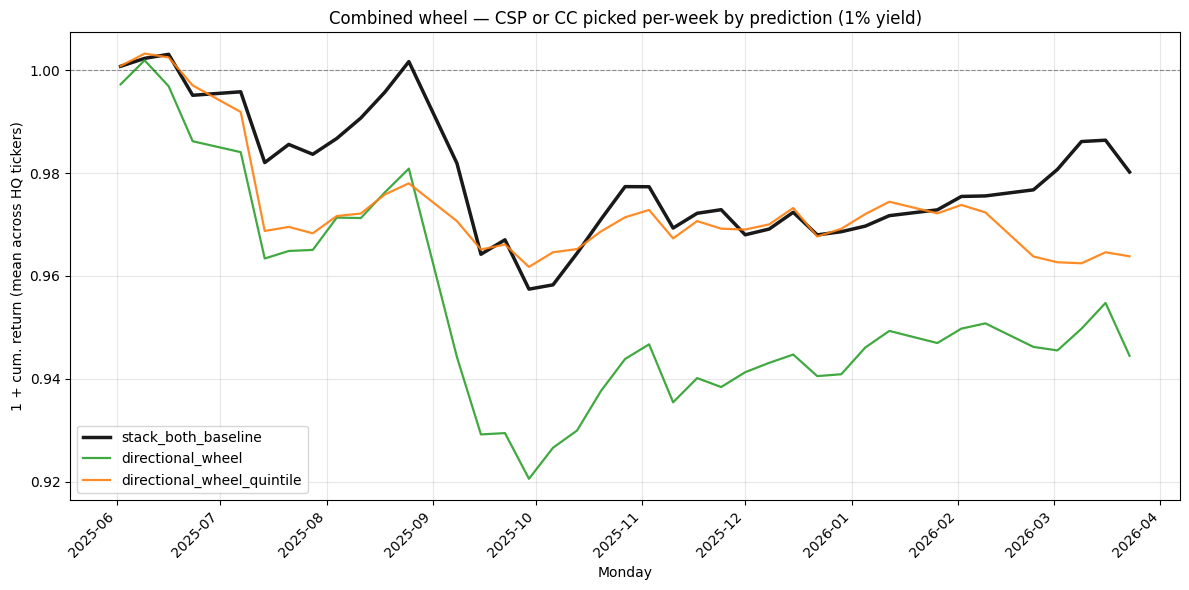

In [10]:
combined_palette = {
    "stack_both_baseline": "black",
    "directional_wheel": "tab:green",
    "directional_wheel_quintile": "tab:orange",
}
plot_equity(
    combined_runs,
    "Combined wheel — CSP or CC picked per-week by prediction (1% yield)",
    "combined_equity.png",
    combined_palette,
)

## All-strategies scoreboard

In [11]:
all_summary = pd.concat([csp_summary, cc_summary, combined_summary], ignore_index=True)
all_summary.to_csv(OUT_DIR / "all_summary.csv", index=False)
print(all_summary.to_string(index=False))

                  strategy  n_trades  pct_weeks_traded  fill_rate_pct  mean_pnl_per_trade_pct  total_return  mean_weekly  std_weekly  sharpe  max_dd  n_weeks
              CSP_baseline      1167             100.0           26.9                   0.023        0.0095       0.0002      0.0083  0.2112 -0.0567       39
              CSP_top_half       581              49.8           28.7                  -0.012       -0.0024      -0.0001      0.0045 -0.0998 -0.0302       39
          CSP_top_quintile       243              20.8           25.1                   0.024        0.0022       0.0001      0.0023  0.1780 -0.0149       39
  CSP_skip_bottom_quintile       950              81.4           27.7                   0.035        0.0116       0.0003      0.0066  0.3241 -0.0444       39
               CC_baseline      1222             100.0           21.4                  -0.136       -0.0569      -0.0015      0.0144 -0.7325 -0.1417       39
            CC_bottom_half       612              50

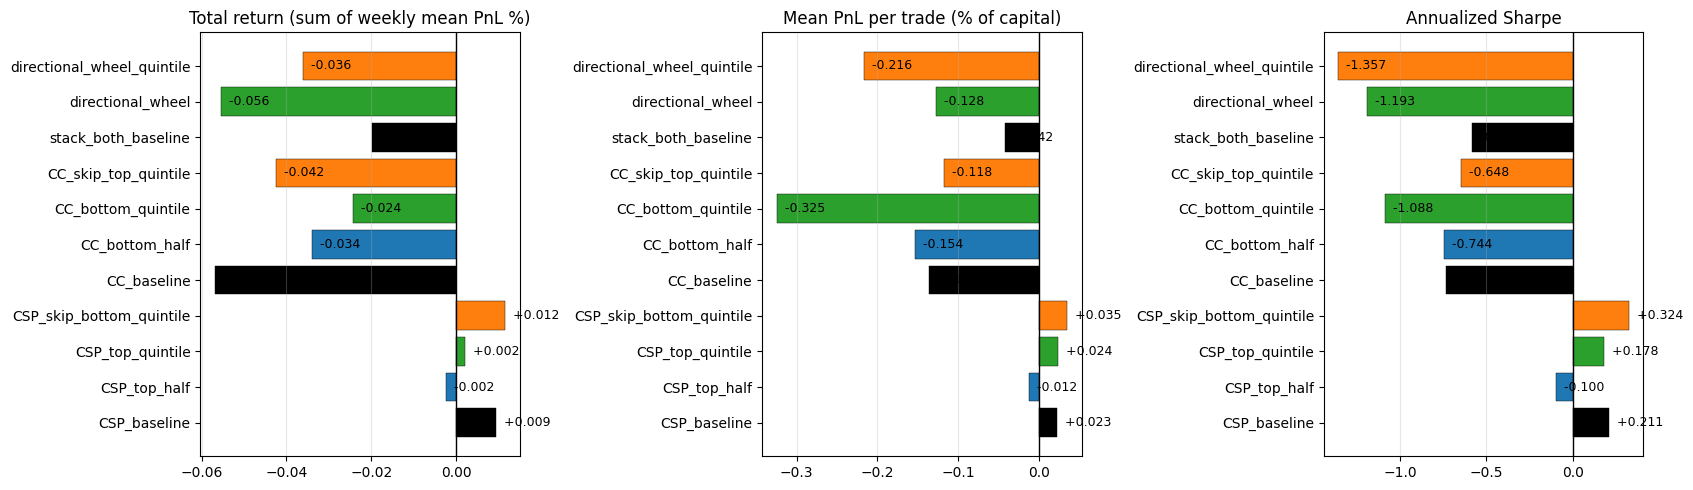

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
strategies = all_summary["strategy"].tolist()
colors_all = {**csp_palette, **cc_palette, **combined_palette}
cols = [colors_all.get(s, "tab:gray") for s in strategies]

for ax, col, title in [
    (axes[0], "total_return", "Total return (sum of weekly mean PnL %)"),
    (axes[1], "mean_pnl_per_trade_pct", "Mean PnL per trade (% of capital)"),
    (axes[2], "sharpe", "Annualized Sharpe"),
]:
    ax.barh(
        strategies,
        all_summary[col].values,
        color=cols,
        edgecolor="black",
        linewidth=0.3,
    )
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.grid(alpha=0.3, axis="x")
    for i, v in enumerate(all_summary[col].values):
        ax.text(v, i, f"  {v:+.3f}", va="center", fontsize=9)

fig.tight_layout()
fig.savefig(OUT_DIR / "scoreboard.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Diagnostics: did the filter actually pick the right weeks?

For each filtered CSP strategy, plot the distribution of realized `forward_ret`
for entered vs skipped trades. If the filter works, entered trades should have
higher realized forward_ret than skipped ones.

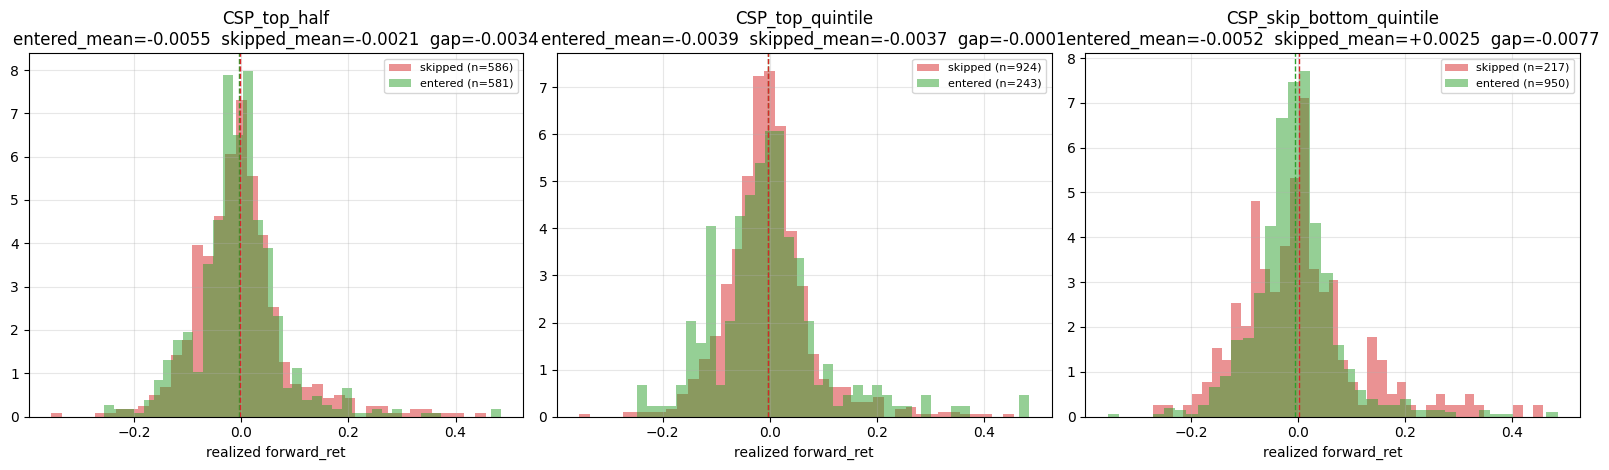

In [13]:
csp_with_ret = csp.merge(
    feat[["ticker", "monday_date", "log_forward_ret"]],
    on=["ticker", "monday_date"],
    how="left",
)
csp_with_ret["forward_ret"] = np.exp(csp_with_ret["log_forward_ret"]) - 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, name in zip(
    axes,
    ["CSP_top_half", "CSP_top_quintile", "CSP_skip_bottom_quintile"],
):
    mask = csp_runs[name]["entered"].values
    entered_rets = csp_with_ret.loc[mask, "forward_ret"]
    skipped_rets = csp_with_ret.loc[~mask, "forward_ret"]
    ax.hist(
        skipped_rets,
        bins=40,
        alpha=0.5,
        color="tab:red",
        label=f"skipped (n={len(skipped_rets)})",
        density=True,
    )
    ax.hist(
        entered_rets,
        bins=40,
        alpha=0.5,
        color="tab:green",
        label=f"entered (n={len(entered_rets)})",
        density=True,
    )
    ax.axvline(entered_rets.mean(), color="tab:green", linestyle="--", linewidth=1)
    ax.axvline(skipped_rets.mean(), color="tab:red", linestyle="--", linewidth=1)
    gap = entered_rets.mean() - skipped_rets.mean()
    ax.set_title(
        f"{name}\nentered_mean={entered_rets.mean():+.4f}  skipped_mean={skipped_rets.mean():+.4f}  gap={gap:+.4f}"
    )
    ax.set_xlabel("realized forward_ret")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "csp_filter_diagnostic.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Conclusion

**Headline**: numerically, `CSP_skip_bottom_quintile` lifts baseline total
return from +0.95% to +1.16% and Sharpe from 0.21 to 0.32 over the 39-week
test window. But the filter diagnostic reveals this is **not** happening
through the mechanism nb 11 promised.

CSP scoreboard (ranked by Sharpe):

| strategy                 | total | Sharpe | fill% | pnl/trade | weeks traded |
|--------------------------|------:|-------:|------:|----------:|--------------|
| CSP_skip_bottom_quintile | +1.16%| +0.32  | 27.7% | +0.035%   | 81%          |
| CSP_baseline             | +0.95%| +0.21  | 26.9% | +0.023%   | 100%         |
| CSP_top_quintile         | +0.22%| +0.18  | 25.1% | +0.024%   | 21%          |
| CSP_top_half             | -0.24%| -0.10  | 28.7% | -0.012%   | 50%          |

**The filter diagnostic (`csp_filter_diagnostic.png`) is the real story:**

- For `CSP_skip_bottom_quintile`: *entered* trades have mean forward_ret
  **-0.52%**; *skipped* trades have mean **+0.25%**. Gap = **-0.77%**.
- For `CSP_top_half` and `CSP_top_quintile`, the gap is similarly negative
  or ~zero.

The filter is *reversing* the predicted direction on this test window —
trades it "keeps" actually dropped more than trades it "skipped". So how
did skip_bottom_quintile still beat baseline on PnL? Most likely because
the filter coincidentally removed a few weeks with extreme drops (an
option PnL outlier doesn't need matching forward_ret rank), not because
the direction signal worked.

**What this actually says about nb 11's +0.12 Spearman:**

1. Spearman rank correlation is not the same as trade selection quality
   for options PnL. Options PnL is **non-linear** in forward return
   (bounded premium + one-sided assignment loss), so even a correctly-
   ranked predictor can fail to improve strategy PnL.
2. The 39-week test window is small. nb 11's Spearman was measured across
   ~1,373 (ticker, week) rows; here we're slicing to 39 weeks × 35
   tickers and losing statistical power.
3. Selection bias is still a concern — `skip_bottom_quintile` was the
   best of 4 CSP variants tried after looking at the results.

**CC is a total loss** at 1% yield on this universe — every variant
negative. The directional filter can't fix a strategy that's structurally
unprofitable.

**Combined wheel** strategies all lose money because the CC leg drags down
any CSP gain.

**Net conclusion**: nb 11's directional signal does not translate to
an options PnL improvement on this test window through the hypothesized
mechanism. The apparent `skip_bottom_quintile` lift is most likely noise
on 39 weeks, not real edge. **The practical recommendation from nb 10 is
unchanged: use `|delta|` as the P(filled) proxy, no ML filter.**

**If we want to keep hunting for an edge:**
- Test on more weeks. The train/test split gives us only 39 weeks; a
  proper walk-forward across 2020-2026 would give ~300 weeks and decide
  this statistically.
- Switch the target. Directional forward_ret is the wrong loss function
  for options PnL. Train directly on `pnl_pct_capital` or on `assigned`
  (the same target nb 08 tried, but with the expanded nb 11 features).
- Test the feature set on a *different* problem (e.g., filtering
  high-quality entry points for a shares-only strategy) to see whether
  the signal has any tradeable expression at all.

In [14]:
csp_summary.to_csv(OUT_DIR / "csp_summary.csv", index=False)
cc_summary.to_csv(OUT_DIR / "cc_summary.csv", index=False)
combined_summary.to_csv(OUT_DIR / "combined_summary.csv", index=False)
pred_df.to_parquet(OUT_DIR / "test_predictions.parquet", index=False)
print(f"saved artifacts to {OUT_DIR}/")

saved artifacts to output\12_directional_model_backtest/
